In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from sktime.classification.compose import ComposableTimeSeriesForestClassifier
from sktime.utils.slope_and_trend import _slope

In [2]:
file = open("timeseries_test_train_labels.csv")
y = np. loadtxt(file, delimiter=",")
print(y)

[ 0.  0.  0.  0.  0.  1.  1.  1.  1.  1.  2.  2.  2.  2.  2.  3.  3.  3.
  3.  3.  4.  4.  4.  4.  4.  5.  5.  5.  5.  5.  6.  6.  6.  6.  6.  7.
  7.  7.  7.  7.  8.  8.  8.  8.  8.  9.  9.  9.  9.  9. 10. 10. 10. 10.
 10. 11. 11. 11. 11. 11.]


In [3]:
file = open("timeseries_test_train_frames.csv")
x = np. loadtxt(file, delimiter=",")
print(x)

[[ 7.  7.  7. ...  7.  7.  7.]
 [11. 11. 11. ...  7. 11.  7.]
 [ 7.  7.  7. ... 10. 10. 10.]
 ...
 [ 7.  7.  7. ... 11. 11. 11.]
 [ 8.  8.  8. ...  7.  7.  7.]
 [ 7.  7.  7. ...  7.  7.  7.]]


In [12]:
filename3 = ('/home/hjones/hctsa_pipeline/timeseries_test_train_output.csv')

In [15]:
data=pd.read_csv(filename3)

In [16]:
#define variables (x= frame data, y= compound name data)
x=data.iloc[:,1:]
y=data.iloc[:,:1]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(45, 1023) (45,) (15, 1023) (15,)


In [5]:
from sktime.classification.interval_based import TimeSeriesForestClassifier
#from sktime.datasets import load_unit_test
#X_train, y_train = load_unit_test(split="train")
#X_test, y_test = load_unit_test(split="test")
clf = TimeSeriesForestClassifier(n_estimators=5)
clf.fit(X_train, y_train)
TimeSeriesForestClassifier(...)
y_pred = clf.predict(X_test)
clf.score(X_test, y_test)

0.06666666666666667

In [6]:
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [16]:
novel = open("novel_frames.csv")
novel_frames = np. loadtxt(novel, delimiter=",")
print(novel_frames)

[[11. 11. 11. ... 10. 10. 10.]
 [ 7.  7.  7. ... 11. 11. 11.]
 [11. 11. 11. ... 10. 10. 10.]
 ...
 [11. 11. 11. ...  7.  7.  7.]
 [ 7.  7.  7. ... 11. 11. 11.]
 [11. 11. 11. ...  7.  7.  7.]]


In [17]:
novel_labels = open("novel_labels.csv")
novel_labels = np. loadtxt(novel_labels, delimiter=",")
print(novel_labels)

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.
  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  5.  5.  5.  5.  5.  5.
  5.  5.  5.  5.  5.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  7.  7.
  7.  7.  7.  7.  7.  7.  7.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.
  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  9.  9.  9.  9.  9.  9.  9.
  9.  9.  9.  9.  9.  9. 10. 10. 10. 10. 10. 11. 11. 11. 11. 11.]


In [18]:
classifier = clf

Confusion matrix, without normalization
[[4 2 0 0 0 4 0 0 0 1 1 2]
 [1 5 0 2 0 1 1 0 0 4 0 0]
 [0 1 2 1 0 1 0 1 3 2 1 0]
 [3 1 0 4 0 2 0 1 1 2 0 0]
 [0 1 0 1 4 0 0 0 2 2 2 0]
 [2 0 0 2 1 4 0 1 0 0 1 0]
 [2 2 0 0 0 1 2 1 1 1 0 1]
 [0 0 0 0 1 0 0 5 0 3 0 0]
 [3 4 0 2 0 2 0 0 6 1 2 2]
 [2 0 0 1 0 4 0 1 2 2 0 1]
 [1 2 0 0 0 2 0 0 0 0 0 0]
 [2 0 0 0 0 2 1 0 0 0 0 0]]
Normalized confusion matrix
[[0.28571429 0.14285714 0.         0.         0.         0.28571429
  0.         0.         0.         0.07142857 0.07142857 0.14285714]
 [0.07142857 0.35714286 0.         0.14285714 0.         0.07142857
  0.07142857 0.         0.         0.28571429 0.         0.        ]
 [0.         0.08333333 0.16666667 0.08333333 0.         0.08333333
  0.         0.08333333 0.25       0.16666667 0.08333333 0.        ]
 [0.21428571 0.07142857 0.         0.28571429 0.         0.14285714
  0.         0.07142857 0.07142857 0.14285714 0.         0.        ]
 [0.         0.08333333 0.         0.08333333 0.33333333 0.

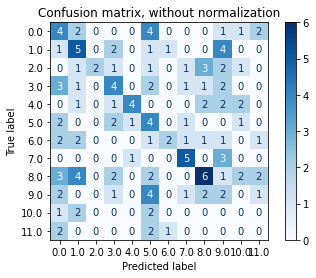

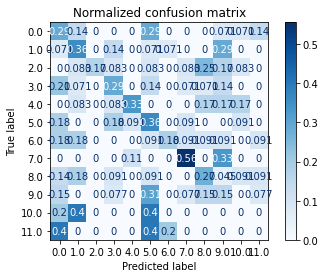

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        classifier,
        novel_frames,
        novel_labels,
        #display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)